In [ ]:
# ============================================================
# SPEECH EMOTION RECOGNITION - PHASE 1
# Data Preparation & Exploratory Data Analysis
# ============================================================

# 1. INSTALL REQUIRED PACKAGES
!pip install librosa soundfile matplotlib seaborn pandas numpy scikit-learn

# 2. IMPORT LIBRARIES
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Setup complete!")

✓ Setup complete!


In [ ]:
!pip install kagglehub


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio
!unzip -qq ravdess-emotional-speech-audio.zip

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
 92% 394M/429M [00:00<00:00, 486MB/s]
100% 429M/429M [00:00<00:00, 517MB/s]


In [ ]:
# 5. ORGANIZE DATASET & CREATE METADATA
import glob

# RAVDESS filename format: 03-01-06-01-02-01-12.wav
# Modality-VocalChannel-Emotion-Intensity-Statement-Repetition-Actor

EMOTION_DICT = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

INTENSITY_DICT = {
    '01': 'normal',
    '02': 'strong'
}

def parse_ravdess_filename(filename):
    """Extract metadata from RAVDESS filename"""
    parts = Path(filename).stem.split('-')

    return {
        'filename': filename,
        'modality': parts[0],
        'vocal_channel': parts[1],
        'emotion': EMOTION_DICT.get(parts[2], 'unknown'),
        'emotion_code': parts[2],
        'intensity': INTENSITY_DICT.get(parts[3], 'unknown'),
        'statement': parts[4],
        'repetition': parts[5],
        'actor': int(parts[6]),
        'gender': 'female' if int(parts[6]) % 2 == 0 else 'male'
    }

# Find all audio files
audio_files = glob.glob('/content/audio_speech_actors_01-24/**/*.wav', recursive=True)
print(f"Found {len(audio_files)} audio files")

# Create metadata dataframe
metadata = pd.DataFrame([parse_ravdess_filename(f) for f in audio_files])

# Get audio duration for each file
print("Extracting audio durations...")
durations = []
for file in audio_files:
    y, sr = librosa.load(file, sr=None)
    durations.append(len(y) / sr)
metadata['duration'] = durations

# Save metadata
metadata.to_csv('ravdess_metadata.csv', index=False)
print(f"✓ Metadata saved! Total samples: {len(metadata)}")

# Display sample
metadata.head()

Found 1440 audio files
Extracting audio durations...
✓ Metadata saved! Total samples: 1440


,filename,modality,vocal_channel,emotion,emotion_code,intensity,statement,repetition,actor,gender,duration
0,/content/audio_speech_actors_01-24/Actor_05/03...,03,01,angry,05,strong,01,02,5,male,3.570229
1,/content/audio_speech_actors_01-24/Actor_05/03...,03,01,angry,05,strong,02,02,5,male,3.636979
2,/content/audio_speech_actors_01-24/Actor_05/03...,03,01,disgust,07,normal,01,02,5,male,4.104104
3,/content/audio_speech_actors_01-24/Actor_05/03...,03,01,calm,02,normal,01,01,5,male,4.037354
4,/content/audio_speech_actors_01-24/Actor_05/03...,03,01,sad,04,normal,01,02,5,male,3.636958


In [ ]:
# 6. EXPLORATORY DATA ANALYSIS

# Create figures directory
os.makedirs('figures', exist_ok=True)

print("="*60)
print("RAVDESS DATASET STATISTICS")
print("="*60)

# Basic statistics
print(f"\nTotal Samples: {len(metadata)}")
print(f"Number of Actors: {metadata['actor'].nunique()}")
print(f"Number of Emotions: {metadata['emotion'].nunique()}")
print(f"\nDuration Statistics:")
print(f"  Mean: {metadata['duration'].mean():.2f}s")
print(f"  Std: {metadata['duration'].std():.2f}s")
print(f"  Min: {metadata['duration'].min():.2f}s")
print(f"  Max: {metadata['duration'].max():.2f}s")

# Emotion distribution
print(f"\nEmotion Distribution:")
print(metadata['emotion'].value_counts().sort_index())

# Gender distribution
print(f"\nGender Distribution:")
print(metadata['gender'].value_counts())

# Intensity distribution
print(f"\nIntensity Distribution:")
print(metadata['intensity'].value_counts())

RAVDESS DATASET STATISTICS

Total Samples: 1440
Number of Actors: 24
Number of Emotions: 8

Duration Statistics:
  Mean: 3.70s
  Std: 0.34s
  Min: 2.94s
  Max: 5.27s

Emotion Distribution:
emotion
angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral       96
sad          192
surprised    192
Name: count, dtype: int64

Gender Distribution:
gender
male      720
female    720
Name: count, dtype: int64

Intensity Distribution:
intensity
normal    768
strong    672
Name: count, dtype: int64


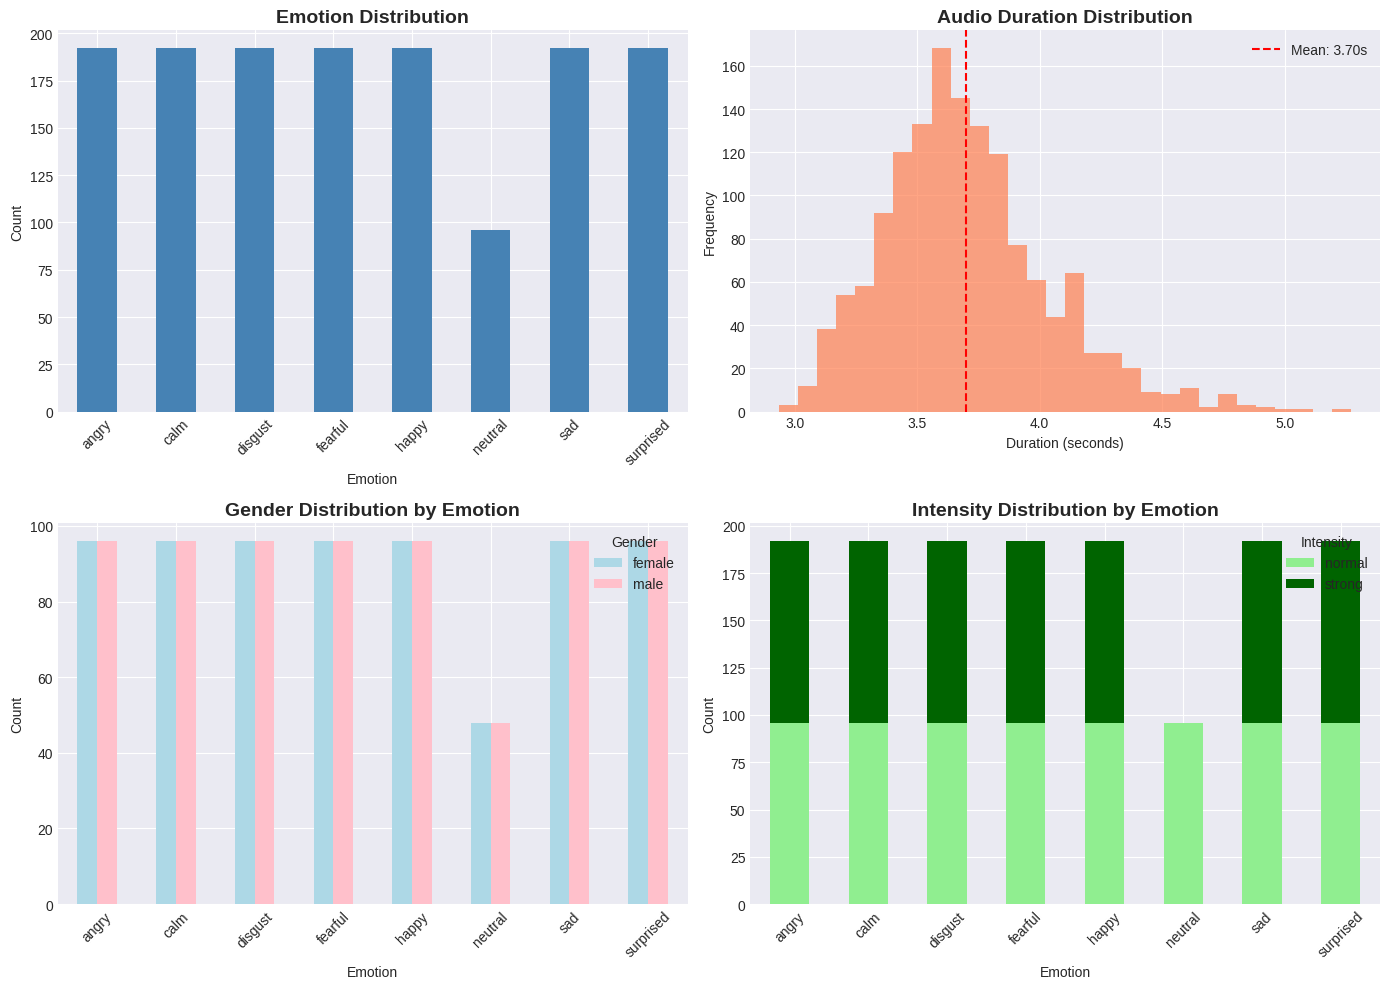

✓ Visualization saved to figures/dataset_statistics.png


In [ ]:
# 7. CREATE VISUALIZATIONS FOR PAPER

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Emotion distribution
metadata['emotion'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,0], color='steelblue'
)
axes[0,0].set_title('Emotion Distribution', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Emotion')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Duration distribution
axes[0,1].hist(metadata['duration'], bins=30, color='coral', alpha=0.7)
axes[0,1].set_title('Audio Duration Distribution', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Duration (seconds)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].axvline(metadata['duration'].mean(), color='red',
                   linestyle='--', label=f"Mean: {metadata['duration'].mean():.2f}s")
axes[0,1].legend()

# Plot 3: Gender by emotion
gender_emotion = pd.crosstab(metadata['emotion'], metadata['gender'])
gender_emotion.plot(kind='bar', ax=axes[1,0], color=['lightblue', 'pink'])
axes[1,0].set_title('Gender Distribution by Emotion', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Emotion')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(title='Gender')

# Plot 4: Intensity by emotion
intensity_emotion = pd.crosstab(metadata['emotion'], metadata['intensity'])
intensity_emotion.plot(kind='bar', stacked=True, ax=axes[1,1],
                       color=['lightgreen', 'darkgreen'])
axes[1,1].set_title('Intensity Distribution by Emotion', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Emotion')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend(title='Intensity')

plt.tight_layout()
plt.savefig('figures/dataset_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to figures/dataset_statistics.png")

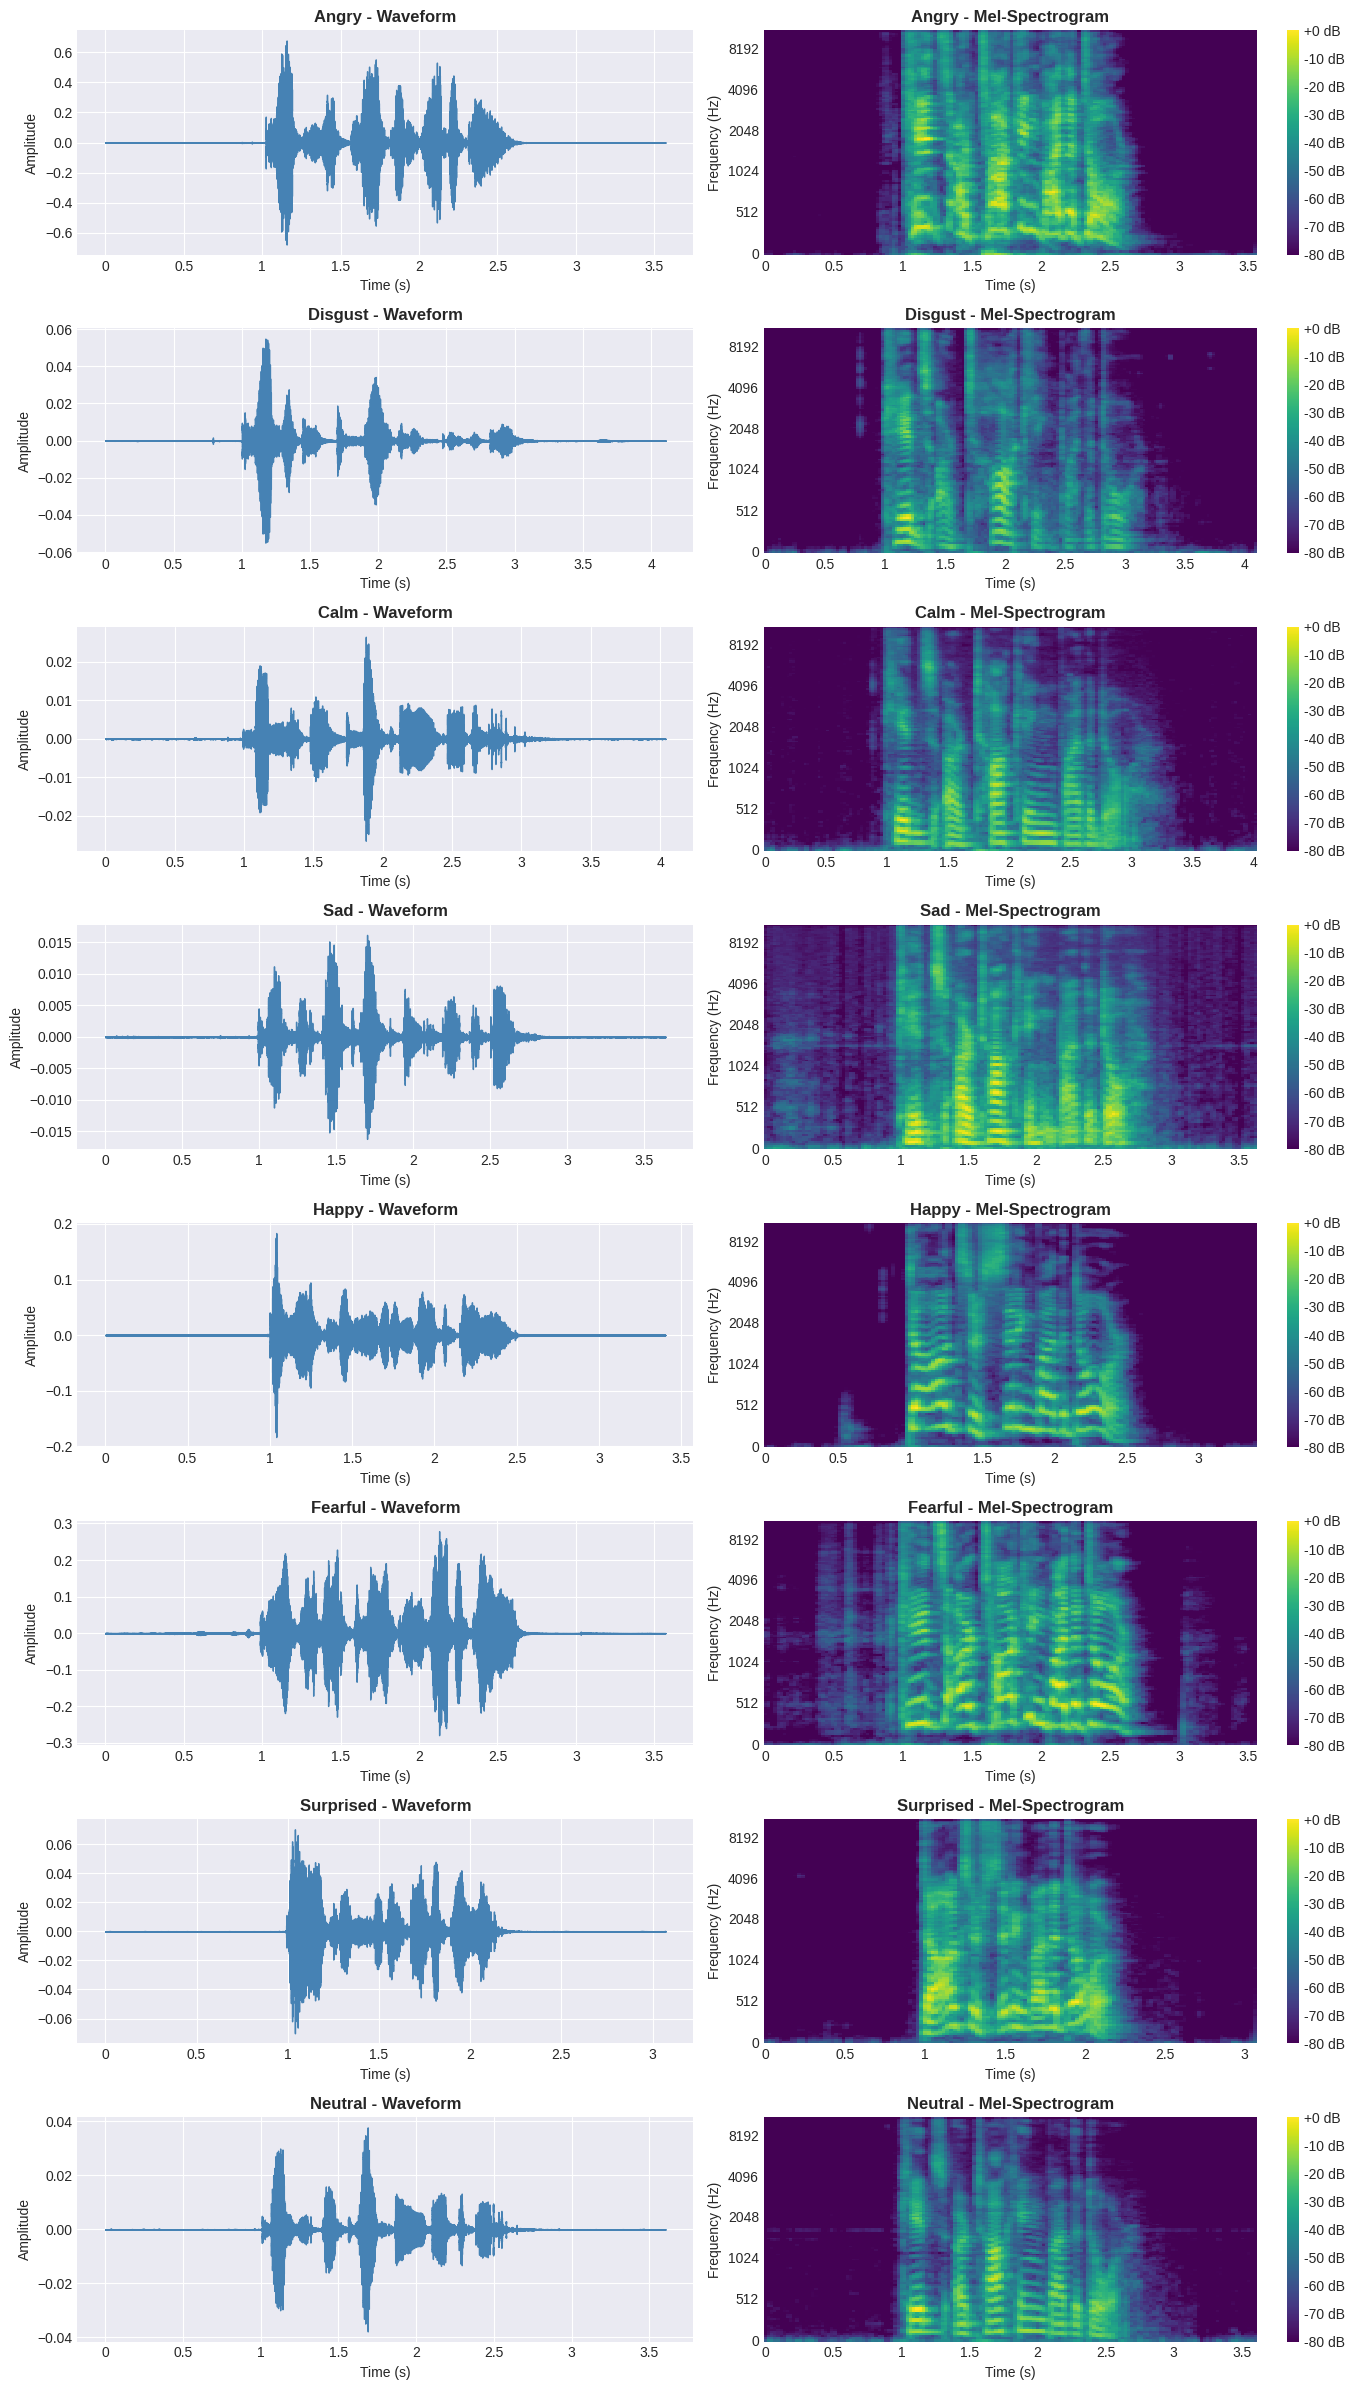

✓ Waveform & Spectrogram visualization saved!


In [ ]:
# 8. VISUALIZE WAVEFORMS & SPECTROGRAMS (For Paper Figure 2)

# Select one sample per emotion
emotion_samples = {}
for emotion in metadata['emotion'].unique():
    sample = metadata[metadata['emotion'] == emotion].iloc[0]
    emotion_samples[emotion] = sample['filename']

# Create figure with 8 emotions x 2 plots (waveform + spectrogram)
fig, axes = plt.subplots(8, 2, figsize=(14, 24))

for idx, (emotion, filepath) in enumerate(emotion_samples.items()):
    # Load audio
    y, sr = librosa.load(filepath, sr=22050)

    # Plot waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[idx, 0], color='steelblue')
    axes[idx, 0].set_title(f'{emotion.capitalize()} - Waveform',
                           fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel('Time (s)')
    axes[idx, 0].set_ylabel('Amplitude')

    # Plot Mel-spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel',
                                    ax=axes[idx, 1], cmap='viridis')
    axes[idx, 1].set_title(f'{emotion.capitalize()} - Mel-Spectrogram',
                           fontsize=12, fontweight='bold')
    axes[idx, 1].set_xlabel('Time (s)')
    axes[idx, 1].set_ylabel('Frequency (Hz)')
    fig.colorbar(img, ax=axes[idx, 1], format='%+2.0f dB')

plt.tight_layout()
plt.savefig('figures/waveforms_spectrograms.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Waveform & Spectrogram visualization saved!")

In [ ]:
# 9. CREATE SPEAKER-INDEPENDENT SPLITS (CRITICAL!)

# Get unique actors
actors = metadata['actor'].unique()
np.random.seed(42)  # For reproducibility
np.random.shuffle(actors)

# Split actors: 60% train, 20% val, 20% test
# Ensure gender balance
male_actors = [a for a in actors if a % 2 == 1]
female_actors = [a for a in actors if a % 2 == 0]

# Split male actors
n_male = len(male_actors)
train_male = male_actors[:int(0.6*n_male)]
val_male = male_actors[int(0.6*n_male):int(0.8*n_male)]
test_male = male_actors[int(0.8*n_male):]

# Split female actors
n_female = len(female_actors)
train_female = female_actors[:int(0.6*n_female)]
val_female = female_actors[int(0.6*n_female):int(0.8*n_female)]
test_female = female_actors[int(0.8*n_female):]

# Combine
train_actors = train_male + train_female
val_actors = val_male + val_female
test_actors = test_male + test_female

print("="*60)
print("SPEAKER-INDEPENDENT SPLIT")
print("="*60)
print(f"Train Actors ({len(train_actors)}): {sorted(train_actors)}")
print(f"  Male: {len(train_male)}, Female: {len(train_female)}")
print(f"\nVal Actors ({len(val_actors)}): {sorted(val_actors)}")
print(f"  Male: {len(val_male)}, Female: {len(val_female)}")
print(f"\nTest Actors ({len(test_actors)}): {sorted(test_actors)}")
print(f"  Male: {len(test_male)}, Female: {len(test_female)}")

# Create split column in metadata
metadata['split'] = 'train'
metadata.loc[metadata['actor'].isin(val_actors), 'split'] = 'val'
metadata.loc[metadata['actor'].isin(test_actors), 'split'] = 'test'

# Verify split distribution
print(f"\nSplit Distribution:")
print(metadata['split'].value_counts())

# Check emotion distribution per split
print(f"\nEmotion Distribution by Split:")
split_emotion = pd.crosstab(metadata['split'], metadata['emotion'])
print(split_emotion)

# Save updated metadata
metadata.to_csv('ravdess_metadata_with_splits.csv', index=False)
print("\n✓ Metadata with splits saved!")

SPEAKER-INDEPENDENT SPLIT
Train Actors (14): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(8), np.int64(10), np.int64(16), np.int64(19), np.int64(20), np.int64(21), np.int64(23), np.int64(24)]
  Male: 7, Female: 7

Val Actors (4): [np.int64(9), np.int64(15), np.int64(18), np.int64(22)]
  Male: 2, Female: 2

Test Actors (6): [np.int64(6), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(17)]
  Male: 3, Female: 3

Split Distribution:
split
train    840
test     360
val      240
Name: count, dtype: int64

Emotion Distribution by Split:
emotion  angry  calm  disgust  fearful  happy  neutral  sad  surprised
split                                                                 
test        48    48       48       48     48       24   48         48
train      112   112      112      112    112       56  112        112
val         32    32       32       32     32       16   32         32

✓ Metadata with splits saved!


In [ ]:
# 10. VERIFY NO DATA LEAKAGE

train_actors_set = set(metadata[metadata['split']=='train']['actor'].unique())
val_actors_set = set(metadata[metadata['split']=='val']['actor'].unique())
test_actors_set = set(metadata[metadata['split']=='test']['actor'].unique())

# Check for overlaps
train_val_overlap = train_actors_set & val_actors_set
train_test_overlap = train_actors_set & test_actors_set
val_test_overlap = val_actors_set & test_actors_set

print("="*60)
print("DATA LEAKAGE CHECK")
print("="*60)
print(f"Train-Val Overlap: {train_val_overlap if train_val_overlap else 'None ✓'}")
print(f"Train-Test Overlap: {train_test_overlap if train_test_overlap else 'None ✓'}")
print(f"Val-Test Overlap: {val_test_overlap if val_test_overlap else 'None ✓'}")

if not any([train_val_overlap, train_test_overlap, val_test_overlap]):
    print("\n✅ NO DATA LEAKAGE - Splits are actor-independent!")
else:
    print("\n⚠️ WARNING: Data leakage detected!")

DATA LEAKAGE CHECK
Train-Val Overlap: None ✓
Train-Test Overlap: None ✓
Val-Test Overlap: None ✓

✅ NO DATA LEAKAGE - Splits are actor-independent!


In [ ]:
import librosa
import numpy as np

SR = 16000
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
N_MFCC = 40


In [ ]:
def extract_spectral_features(audio, sr=SR):
    # Mel-spectrogram
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # MFCCs
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=N_MFCC,
        hop_length=HOP_LENGTH
    )

    # Deltas
    delta_mfcc = librosa.feature.delta(mfcc)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)

    # Stack features
    spectral_features = np.vstack([
        mel_db,
        mfcc,
        delta_mfcc,
        delta2_mfcc
    ])

    # Shape: (248, T)
    return spectral_features


In [ ]:
def extract_prosodic_features(audio, sr=SR):
    # Pitch (F0)
    f0, voiced_flag, voiced_prob = librosa.pyin(
        audio,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7"),
        sr=sr,
        hop_length=HOP_LENGTH
    )
    f0 = np.nan_to_num(f0)

    # Energy
    rms = librosa.feature.rms(
        y=audio,
        hop_length=HOP_LENGTH
    )[0]

    # Spectral centroid
    centroid = librosa.feature.spectral_centroid(
        y=audio,
        sr=sr,
        hop_length=HOP_LENGTH
    )[0]

    # Zero-crossing rate
    zcr = librosa.feature.zero_crossing_rate(
        audio,
        hop_length=HOP_LENGTH
    )[0]

    # Temporal derivatives
    f0_delta = np.gradient(f0)
    rms_delta = np.gradient(rms)
    zcr_delta = np.gradient(zcr)

    # Stack → (8, T)
    prosodic_features = np.vstack([
        f0,
        voiced_prob,
        rms,
        centroid,
        zcr,
        f0_delta,
        rms_delta,
        zcr_delta
    ])

    return prosodic_features


In [ ]:
def extract_features(audio_path):
    try:
        audio, sr = librosa.load(audio_path, sr=SR)

        spectral = extract_spectral_features(audio, sr)
        prosodic = extract_prosodic_features(audio, sr)

        # Ensure temporal alignment
        T = min(spectral.shape[1], prosodic.shape[1])
        spectral = spectral[:, :T]
        prosodic = prosodic[:, :T]

        return spectral, prosodic

    except Exception as e:
        print(f"Failed on {audio_path}: {e}")
        return None, None


In [ ]:
df = pd.read_csv("ravdess_metadata_with_splits.csv")

print(f"\n✓ Loaded {len(df)} samples")
print(f"✓ Columns: {df.columns.tolist()}")

# Verify splits exist
assert 'split' in df.columns, "ERROR: No 'split' column! Use metadata from Phase 1"
print(f"\nSplit distribution:")
print(df['split'].value_counts())

# Create emotion label mapping (0-7)
emotion_mapping = {
    '01': 0,  # neutral
    '02': 1,  # calm
    '03': 2,  # happy
    '04': 3,  # sad
    '05': 4,  # angry
    '06': 5,  # fearful
    '07': 6,  # disgust
    '08': 7   # surprised
}

# FIX: Ensure emotion_code is string type with leading zeros before mapping
df['emotion_code'] = df['emotion_code'].astype(str).str.zfill(2)
df['label'] = df['emotion_code'].map(emotion_mapping)

# Verify no missing labels
assert df['label'].notna().all(), "ERROR: Some emotions couldn't be mapped!"
print(f"\n✓ Emotion labels mapped: {df['label'].unique()}")


✓ Loaded 1440 samples
✓ Columns: ['filename', 'modality', 'vocal_channel', 'emotion', 'emotion_code', 'intensity', 'statement', 'repetition', 'actor', 'gender', 'duration', 'split']

Split distribution:
split
train    840
test     360
val      240
Name: count, dtype: int64

✓ Emotion labels mapped: [4 6 1 3 2 5 7 0]


In [ ]:
from tqdm.notebook import tqdm

def process_split(df_split, split_name):
    """Process a single split (train/val/test)"""
    print(f"\n{'='*60}")
    print(f"Processing {split_name.upper()} set ({len(df_split)} samples)")
    print(f"{'='*60}")

    X_spec = []
    X_pros = []
    y = []
    failed = []

    for idx, row in tqdm(df_split.iterrows(), total=len(df_split), desc=split_name):
        spec, pros = extract_features(row['filename'])

        if spec is not None:
            X_spec.append(spec.T)   # (T, 248)
            X_pros.append(pros.T)   # (T, 8)
            y.append(row['label'])
        else:
            failed.append(row['filename'])

    if failed:
        print(f"\n⚠️ Failed to extract {len(failed)} files:")
        for f in failed[:5]:  # Show first 5
            print(f"  - {f}")

    print(f"✓ Successfully extracted {len(X_spec)} samples")

    return X_spec, X_pros, np.array(y)

# Process each split separately
train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'val']
test_df = df[df['split'] == 'test']

X_spec_train, X_pros_train, y_train = process_split(train_df, 'train')
X_spec_val, X_pros_val, y_val = process_split(val_df, 'val')
X_spec_test, X_pros_test, y_test = process_split(test_df, 'test')


Processing TRAIN set (840 samples)


train:   0%|          | 0/840 [00:00<?, ?it/s]

✓ Successfully extracted 840 samples

Processing VAL set (240 samples)


val:   0%|          | 0/240 [00:00<?, ?it/s]

✓ Successfully extracted 240 samples

Processing TEST set (360 samples)


test:   0%|          | 0/360 [00:00<?, ?it/s]

✓ Successfully extracted 360 samples


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

print(f"\n{'='*60}")
print("PADDING SEQUENCES")
print(f"{'='*60}")

# Find max length across ALL splits for consistent padding
all_lengths = (
    [x.shape[0] for x in X_spec_train] +
    [x.shape[0] for x in X_spec_val] +
    [x.shape[0] for x in X_spec_test]
)
max_len = max(all_lengths)
mean_len = np.mean(all_lengths)

print(f"Sequence lengths:")
print(f"  Min: {min(all_lengths)} frames")
print(f"  Mean: {mean_len:.1f} frames")
print(f"  Max: {max_len} frames")
print(f"  Padding to: {max_len} frames")

# Pad all splits to same length
X_spec_train_pad = pad_sequences(X_spec_train, maxlen=max_len, padding='post', dtype='float32')
X_pros_train_pad = pad_sequences(X_pros_train, maxlen=max_len, padding='post', dtype='float32')

X_spec_val_pad = pad_sequences(X_spec_val, maxlen=max_len, padding='post', dtype='float32')
X_pros_val_pad = pad_sequences(X_pros_val, maxlen=max_len, padding='post', dtype='float32')

X_spec_test_pad = pad_sequences(X_spec_test, maxlen=max_len, padding='post', dtype='float32')
X_pros_test_pad = pad_sequences(X_pros_test, maxlen=max_len, padding='post', dtype='float32')

print(f"\n✓ Padded shapes:")
print(f"  Train spectral: {X_spec_train_pad.shape}")
print(f"  Train prosodic: {X_pros_train_pad.shape}")


PADDING SEQUENCES
Sequence lengths:
  Min: 92 frames
  Mean: 116.1 frames
  Max: 165 frames
  Padding to: 165 frames

✓ Padded shapes:
  Train spectral: (840, 165, 248)
  Train prosodic: (840, 165, 8)


In [ ]:
from sklearn.preprocessing import StandardScaler

print(f"\n{'='*60}")
print("FEATURE NORMALIZATION")
print(f"{'='*60}")

# IMPORTANT: Fit scaler on TRAINING data only!
# Then apply to val/test to avoid data leakage

# Spectral normalization
spec_scaler = StandardScaler()

# Reshape for scaler: (samples * time, features)
train_spec_flat = X_spec_train_pad.reshape(-1, X_spec_train_pad.shape[-1])
spec_scaler.fit(train_spec_flat)

# Apply to all splits
X_spec_train_norm = spec_scaler.transform(
    X_spec_train_pad.reshape(-1, X_spec_train_pad.shape[-1])
).reshape(X_spec_train_pad.shape)


FEATURE NORMALIZATION


In [ ]:
X_spec_val_norm = spec_scaler.transform(
    X_spec_val_pad.reshape(-1, X_spec_val_pad.shape[-1])
).reshape(X_spec_val_pad.shape)

X_spec_test_norm = spec_scaler.transform(
    X_spec_test_pad.reshape(-1, X_spec_test_pad.shape[-1])
).reshape(X_spec_test_pad.shape)

# Prosodic normalization
pros_scaler = StandardScaler()

train_pros_flat = X_pros_train_pad.reshape(-1, X_pros_train_pad.shape[-1])
pros_scaler.fit(train_pros_flat)

X_pros_train_norm = pros_scaler.transform(
    X_pros_train_pad.reshape(-1, X_pros_train_pad.shape[-1])
).reshape(X_pros_train_pad.shape)

X_pros_val_norm = pros_scaler.transform(
    X_pros_val_pad.reshape(-1, X_pros_val_pad.shape[-1])
).reshape(X_pros_val_pad.shape)

X_pros_test_norm = pros_scaler.transform(
    X_pros_test_pad.reshape(-1, X_pros_test_pad.shape[-1])
).reshape(X_pros_test_pad.shape)

print("✓ Spectral features normalized")
print(f"  Mean: {X_spec_train_norm.mean():.4f} (should be ~0)")
print(f"  Std: {X_spec_train_norm.std():.4f} (should be ~1)")

print("✓ Prosodic features normalized")
print(f"  Mean: {X_pros_train_norm.mean():.4f} (should be ~0)")
print(f"  Std: {X_pros_train_norm.std():.4f} (should be ~1)")

✓ Spectral features normalized
  Mean: -0.0000 (should be ~0)
  Std: 1.0000 (should be ~1)
✓ Prosodic features normalized
  Mean: 0.0000 (should be ~0)
  Std: 1.0000 (should be ~1)


In [ ]:
import pickle
import os
import numpy as np

print(f"\n{'='*60}")
print("SAVING FEATURES")
print(f"{'='*60}")

# Create output directory
os.makedirs('features', exist_ok=True)

# Save training data
np.save('features/X_spec_train.npy', X_spec_train_norm)
np.save('features/X_pros_train.npy', X_pros_train_norm)
np.save('features/y_train.npy', y_train)

# Save validation data
np.save('features/X_spec_val.npy', X_spec_val_norm)
np.save('features/X_pros_val.npy', X_pros_val_norm)
np.save('features/y_val.npy', y_val)

# Save test data
np.save('features/X_spec_test.npy', X_spec_test_norm)
np.save('features/X_pros_test.npy', X_pros_test_norm)
np.save('features/y_test.npy', y_test)

# Save scalers for later use
with open('features/scalers.pkl', 'wb') as f:
    pickle.dump({
        'spectral_scaler': spec_scaler,
        'prosodic_scaler': pros_scaler,
        'max_len': max_len
    }, f)

print("\n✓ Saved files:")
print("  features/X_spec_train.npy")
print("  features/X_pros_train.npy")
print("  features/y_train.npy")
print("  features/X_spec_val.npy")
print("  features/X_pros_val.npy")
print("  features/y_val.npy")
print("  features/X_spec_test.npy")
print("  features/X_pros_test.npy")
print("  features/y_test.npy")
print("  features/scalers.pkl")


SAVING FEATURES

✓ Saved files:
  features/X_spec_train.npy
  features/X_pros_train.npy
  features/y_train.npy
  features/X_spec_val.npy
  features/X_pros_val.npy
  features/y_val.npy
  features/X_spec_test.npy
  features/X_pros_test.npy
  features/y_test.npy
  features/scalers.pkl


In [ ]:

print(f"\n{'='*60}")
print("PHASE 2 COMPLETE! ✅")
print(f"{'='*60}")

print("\nFinal Dataset Statistics:")
print(f"  Training samples: {len(y_train)}")
print(f"  Validation samples: {len(y_val)}")
print(f"  Test samples: {len(y_test)}")
print(f"  Total samples: {len(y_train) + len(y_val) + len(y_test)}")

print(f"\nFeature shapes:")
print(f"  Spectral: (samples, {max_len}, 248)")
print(f"  Prosodic: (samples, {max_len}, 8)")

print(f"\nClass distribution (training):")
emotion_names = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
for i in range(8):
    count = np.sum(y_train == i)
    print(f"  {emotion_names[i]:10s}: {count} samples")

print(f"\nMemory usage:")
total_mb = (
    X_spec_train_norm.nbytes + X_pros_train_norm.nbytes +
    X_spec_val_norm.nbytes + X_pros_val_norm.nbytes +
    X_spec_test_norm.nbytes + X_pros_test_norm.nbytes
) / (1024**2)
print(f"  Total: {total_mb:.1f} MB")

print(f"\n{'='*60}")
print("READY FOR PHASE 3: BASELINE MODELS")
print(f"{'='*60}")


PHASE 2 COMPLETE! ✅

Final Dataset Statistics:
  Training samples: 840
  Validation samples: 240
  Test samples: 360
  Total samples: 1440

Feature shapes:
  Spectral: (samples, 165, 248)
  Prosodic: (samples, 165, 8)

Class distribution (training):
  neutral   : 56 samples
  calm      : 112 samples
  happy     : 112 samples
  sad       : 112 samples
  angry     : 112 samples
  fearful   : 112 samples
  disgust   : 112 samples
  surprised : 112 samples

Memory usage:
  Total: 232.0 MB

READY FOR PHASE 3: BASELINE MODELS


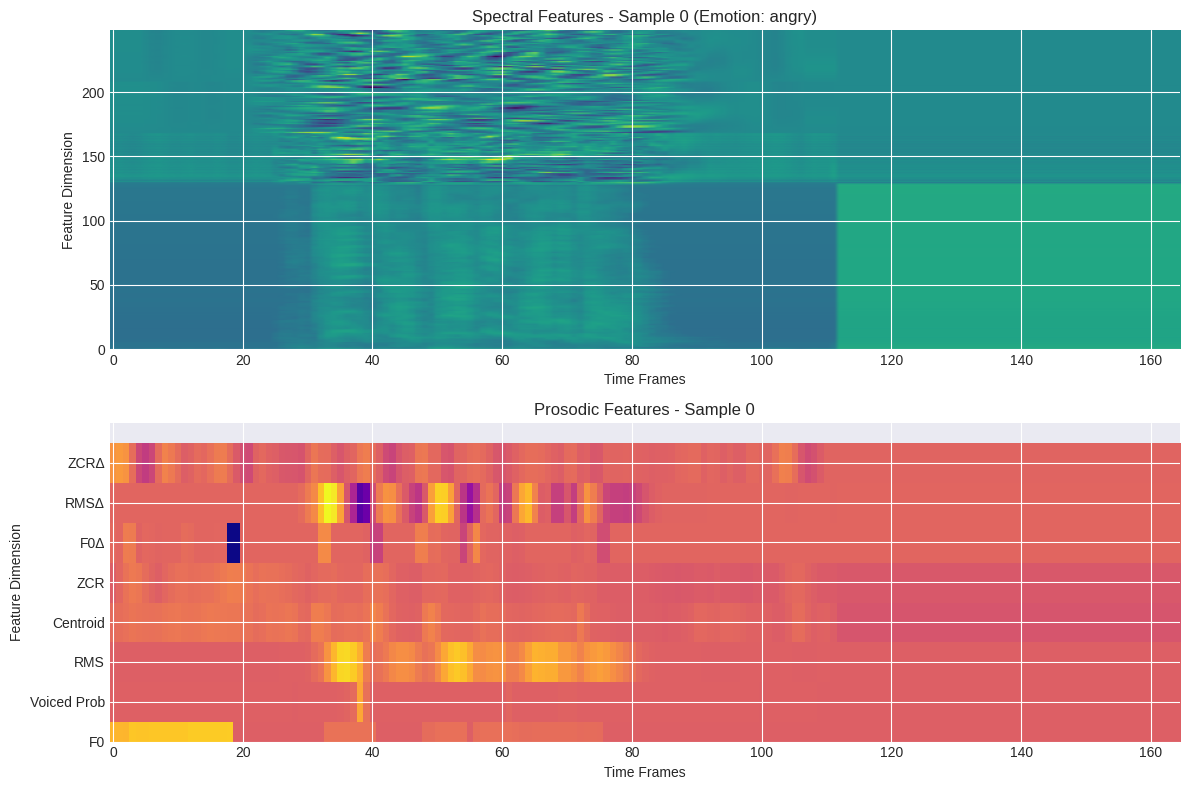


✓ Feature visualization saved to features/sample_features.png


In [ ]:
import matplotlib.pyplot as plt

def visualize_sample_features(idx=0):
    """Visualize features for one sample"""
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # Spectral features
    axes[0].imshow(X_spec_train_norm[idx].T, aspect='auto', cmap='viridis', origin='lower')
    axes[0].set_title(f'Spectral Features - Sample {idx} (Emotion: {emotion_names[y_train[idx]]})')
    axes[0].set_xlabel('Time Frames')
    axes[0].set_ylabel('Feature Dimension')
    axes[0].set_ylim([0, 248])

    # Prosodic features
    axes[1].imshow(X_pros_train_norm[idx].T, aspect='auto', cmap='plasma', origin='lower')
    axes[1].set_title(f'Prosodic Features - Sample {idx}')
    axes[1].set_xlabel('Time Frames')
    axes[1].set_ylabel('Feature Dimension')
    axes[1].set_ylim([0, 8])
    axes[1].set_yticks(range(8))
    axes[1].set_yticklabels(['F0', 'Voiced Prob', 'RMS', 'Centroid', 'ZCR', 'F0Δ', 'RMSΔ', 'ZCRΔ'])

    plt.tight_layout()
    plt.savefig('features/sample_features.png', dpi=150)
    plt.show()

    print("\n✓ Feature visualization saved to features/sample_features.png")

# Uncomment to visualize
visualize_sample_features(idx=0)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

print("TensorFlow version:", tf.__version__)

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.19.0


In [ ]:
print("\n" + "="*60)
print("LOADING DATA")
print("="*60)

X_spec_train = np.load('features/X_spec_train.npy')
X_pros_train = np.load('features/X_pros_train.npy')
y_train = np.load('features/y_train.npy')

X_spec_val = np.load('features/X_spec_val.npy')
X_pros_val = np.load('features/X_pros_val.npy')
y_val = np.load('features/y_val.npy')

X_spec_test = np.load('features/X_spec_test.npy')
X_pros_test = np.load('features/X_pros_test.npy')
y_test = np.load('features/y_test.npy')

print(f"Train: {X_spec_train.shape[0]} samples")
print(f"Val: {X_spec_val.shape[0]} samples")
print(f"Test: {X_spec_test.shape[0]} samples")



LOADING DATA
Train: 840 samples
Val: 240 samples
Test: 360 samples


In [ ]:
train_counts = np.bincount(y_train)
total = len(y_train)
class_weights = {i: total / (8 * count) for i, count in enumerate(train_counts)}

print(f"\nClass distribution: {train_counts}")
print(f"Class weights: {class_weights}")

# Create directories
os.makedirs('results', exist_ok=True)
os.makedirs('models', exist_ok=True)

EMOTION_NAMES = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
NUM_CLASSES = 8


Class distribution: [ 56 112 112 112 112 112 112 112]
Class weights: {0: np.float64(1.875), 1: np.float64(0.9375), 2: np.float64(0.9375), 3: np.float64(0.9375), 4: np.float64(0.9375), 5: np.float64(0.9375), 6: np.float64(0.9375), 7: np.float64(0.9375)}


In [ ]:
def plot_confusion_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTION_NAMES,
                yticklabels=EMOTION_NAMES)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

def plot_history(history, title, save_path):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title(f'{title} - Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title(f'{title} - Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    f1_macro = f1_score(y_true, y_pred, average='macro')

    print(f'\n{model_name} Results:')
    print(f'  Test Accuracy: {accuracy:.4f}')
    print(f'  F1-Score (weighted): {f1_weighted:.4f}')
    print(f'  F1-Score (macro): {f1_macro:.4f}')

    report = classification_report(y_true, y_pred, target_names=EMOTION_NAMES, digits=4)
    print(f'\n{report}')

    return {
        'accuracy': float(accuracy),
        'f1_weighted': float(f1_weighted),
        'f1_macro': float(f1_macro),
        'report': report
    }

In [ ]:
print("\n" + "="*60)
print("BASELINE 1: CNN-ONLY (SPECTRAL)")
print("="*60)

def build_cnn_baseline(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # Add masking for padded sequences
    x = layers.Masking(mask_value=0.0)(inputs)

    # Conv blocks
    x = layers.Conv1D(64, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(128, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(256, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Classification
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs=inputs, outputs=outputs, name='CNN_Baseline')

cnn_model = build_cnn_baseline(
    input_shape=(X_spec_train.shape[1], X_spec_train.shape[2]),
    num_classes=NUM_CLASSES
)

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # LOWER LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
    ModelCheckpoint('models_corrected/cnn_baseline.keras', save_best_only=True,
                   monitor='val_accuracy', verbose=1)
]

print("Training CNN baseline...")
cnn_history = cnn_model.fit(
    X_spec_train, y_train,
    validation_data=(X_spec_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,  # CRITICAL FIX!
    callbacks=cnn_callbacks,
    verbose=1
)

# Evaluate
y_pred_cnn = np.argmax(cnn_model.predict(X_spec_test, verbose=0), axis=1)
cnn_results = evaluate_model(y_test, y_pred_cnn, "CNN Baseline")

plot_history(cnn_history, "CNN Baseline", "results_corrected/history_cnn.png")
plot_confusion_matrix(y_test, y_pred_cnn, "CNN Baseline", "results_corrected/cm_cnn.png")


BASELINE 1: CNN-ONLY (SPECTRAL)
Training CNN baseline...
Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.1315 - loss: 2.2042
Epoch 1: val_accuracy improved from -inf to 0.13333, saving model to models_corrected/cnn_baseline.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 220ms/step - accuracy: 0.1312 - loss: 2.2042 - val_accuracy: 0.1333 - val_loss: 2.0878 - learning_rate: 1.0000e-04
Epoch 2/100
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1845 - loss: 2.0705
Epoch 2: val_accuracy did not improve from 0.13333
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1843 - loss: 2.0721 - val_accuracy: 0.1333 - val_loss: 2.0712 - learning_rate: 1.0000e-04
Epoch 3/100
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1978 - loss: 2.0007
Epoch 3: val_accuracy improved from 0.13333 to 0.15417, saving model to models_corrected/cnn_baseline.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.1973 - loss: 2.0008 - val_accuracy: 0.1542 - val_loss: 2.0406 - learning_rate

In [ ]:
print("\n" + "="*60)
print("BASELINE 2: BI-LSTM ONLY (SPECTRAL)")
print("="*60)

def build_lstm_baseline(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # Masking
    x = layers.Masking(mask_value=0.0)(inputs)

    # Bi-LSTM layers
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.3))(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=False, dropout=0.3))(x)

    # Classification
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs=inputs, outputs=outputs, name='LSTM_Baseline')

lstm_model = build_lstm_baseline(
    input_shape=(X_spec_train.shape[1], X_spec_train.shape[2]),
    num_classes=NUM_CLASSES
)

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # LOWER LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
    ModelCheckpoint('models_corrected/lstm_baseline.keras', save_best_only=True,
                   monitor='val_accuracy', verbose=1)
]

print("Training LSTM baseline...")
lstm_history = lstm_model.fit(
    X_spec_train, y_train,
    validation_data=(X_spec_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,  # CRITICAL FIX!
    callbacks=lstm_callbacks,
    verbose=1
)

# Evaluate
y_pred_lstm = np.argmax(lstm_model.predict(X_spec_test, verbose=0), axis=1)
lstm_results = evaluate_model(y_test, y_pred_lstm, "LSTM Baseline")

plot_history(lstm_history, "LSTM Baseline", "results_corrected/history_lstm.png")
plot_confusion_matrix(y_test, y_pred_lstm, "LSTM Baseline", "results_corrected/cm_lstm.png")


BASELINE 2: BI-LSTM ONLY (SPECTRAL)
Training LSTM baseline...
Epoch 1/100
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.0962 - loss: 2.1419
Epoch 1: val_accuracy improved from -inf to 0.12500, saving model to models_corrected/lstm_baseline.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.0967 - loss: 2.1421 - val_accuracy: 0.1250 - val_loss: 2.0749 - learning_rate: 1.0000e-04
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1324 - loss: 2.0874
Epoch 2: val_accuracy improved from 0.12500 to 0.13333, saving model to models_corrected/lstm_baseline.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.1321 - loss: 2.0882 - val_accuracy: 0.1333 - val_loss: 2.0760 - learning_rate: 1.0000e-04
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1338 - loss: 2.0783
Epoch 3: val_accuracy did not improve from 0.13333
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.1333 - loss: 2.0792 - val_accuracy: 0.1208 - val_loss: 2.0784 - learni

In [ ]:
print("\n" + "="*60)
print("BASELINE 3: CONCATENATION FUSION")
print("="*60)

def build_concat_fusion(spec_shape, pros_shape, num_classes):
    # Spectral stream
    spec_input = layers.Input(shape=spec_shape, name='spectral')
    x_spec = layers.Masking(mask_value=0.0)(spec_input)

    x_spec = layers.Conv1D(64, 5, padding='same', activation='relu')(x_spec)
    x_spec = layers.MaxPooling1D(2)(x_spec)
    x_spec = layers.Conv1D(128, 5, padding='same', activation='relu')(x_spec)
    x_spec = layers.MaxPooling1D(2)(x_spec)
    x_spec = layers.Conv1D(256, 5, padding='same', activation='relu')(x_spec)
    x_spec = layers.GlobalAveragePooling1D()(x_spec)

    # Prosodic stream (temporal processing)
    pros_input = layers.Input(shape=pros_shape, name='prosodic')
    x_pros = layers.Masking(mask_value=0.0)(pros_input)

    x_pros = layers.Dense(64, activation='relu')(x_pros)
    x_pros = layers.Bidirectional(layers.LSTM(128, return_sequences=False, dropout=0.3))(x_pros)

    # Concatenate
    concat = layers.Concatenate()([x_spec, x_pros])

    # Classification
    x = layers.Dense(256, activation='relu')(concat)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs=[spec_input, pros_input], outputs=outputs,
                 name='Concat_Fusion')

concat_model = build_concat_fusion(
    spec_shape=(X_spec_train.shape[1], X_spec_train.shape[2]),
    pros_shape=(X_pros_train.shape[1], X_pros_train.shape[2]),
    num_classes=NUM_CLASSES
)

concat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # LOWER LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

concat_callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
    ModelCheckpoint('models_corrected/concat_fusion.keras', save_best_only=True,
                   monitor='val_accuracy', verbose=1)
]

print("Training concatenation fusion baseline...")
concat_history = concat_model.fit(
    [X_spec_train, X_pros_train], y_train,
    validation_data=([X_spec_val, X_pros_val], y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,  # CRITICAL FIX!
    callbacks=concat_callbacks,
    verbose=1
)

# Evaluate
y_pred_concat = np.argmax(concat_model.predict([X_spec_test, X_pros_test], verbose=0), axis=1)
concat_results = evaluate_model(y_test, y_pred_concat, "Concat Fusion")

plot_history(concat_history, "Concat Fusion", "results_corrected/history_concat.png")
plot_confusion_matrix(y_test, y_pred_concat, "Concat Fusion", "results_corrected/cm_concat.png")


BASELINE 3: CONCATENATION FUSION
Training concatenation fusion baseline...
Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1318 - loss: 2.1009
Epoch 1: val_accuracy improved from -inf to 0.13750, saving model to models_corrected/concat_fusion.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.1315 - loss: 2.1015 - val_accuracy: 0.1375 - val_loss: 2.0632 - learning_rate: 1.0000e-04
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1608 - loss: 2.0588
Epoch 2: val_accuracy improved from 0.13750 to 0.20833, saving model to models_corrected/concat_fusion.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1607 - loss: 2.0594 - val_accuracy: 0.2083 - val_loss: 2.0509 - learning_rate: 1.0000e-04
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2059 - loss: 2.0188
Epoch 3: val_accuracy improved from 0.20833 to 0.26667, saving model to models_corrected/concat_fusion.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.


Model                Accuracy     F1 (weighted) F1 (macro)  
------------------------------------------------------------
CNN Baseline         0.4111       0.3844       0.3774      
LSTM Baseline        0.2028       0.1171       0.1098      
Concat Fusion        0.4528       0.4190       0.4186      


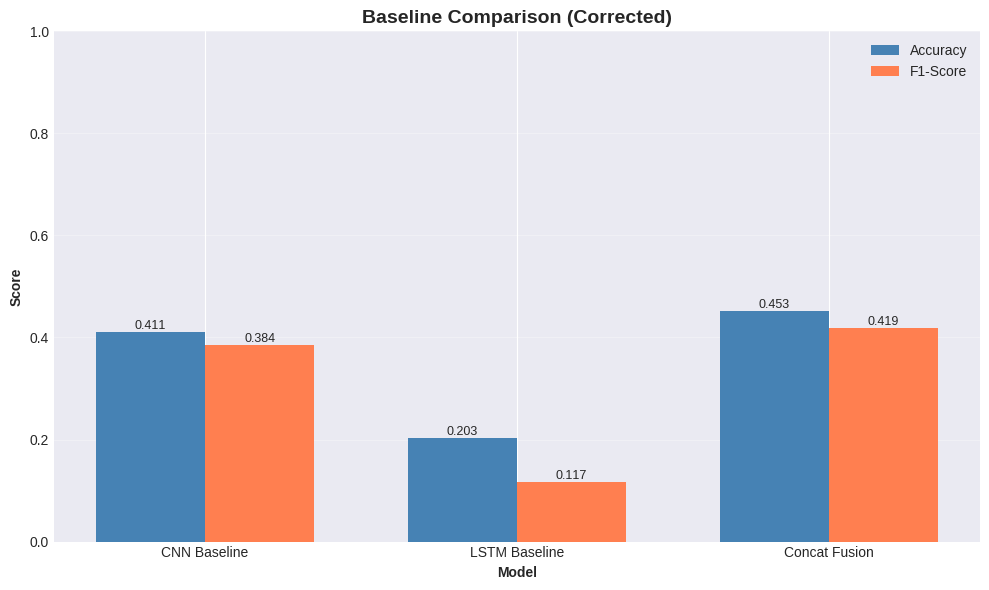


✅ PHASE 3 COMPLETE WITH FIXES!

Expected results:
  CNN-only: 65-75% accuracy
  LSTM-only: 60-70% accuracy
  Concat Fusion: 72-78% accuracy

All results saved to results_corrected/


In [ ]:
print("\n{:<20} {:<12} {:<12} {:<12}".format("Model", "Accuracy", "F1 (weighted)", "F1 (macro)"))
print("-" * 60)

results = {
    "CNN Baseline": cnn_results,
    "LSTM Baseline": lstm_results,
    "Concat Fusion": concat_results
}

for name, res in results.items():
    print("{:<20} {:<12.4f} {:<12.4f} {:<12.4f}".format(
        name, res['accuracy'], res['f1_weighted'], res['f1_macro']
    ))

# Ensure the directory exists before saving
os.makedirs('results_corrected', exist_ok=True)

# Save
with open('results_corrected/baseline_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Comparison plot
fig, ax = plt.subplots(figsize=(10, 6))
models = list(results.keys())
accuracies = [results[m]['accuracy'] for m in models]
f1_scores = [results[m]['f1_weighted'] for m in models]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='coral')

ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Baseline Comparison (Corrected)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.0])

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('results_corrected/baseline_comparison.png', dpi=300)
plt.show()

print("\n✅ PHASE 3 COMPLETE WITH FIXES!")
print("\nExpected results:")
print("  CNN-only: 65-75% accuracy")
print("  LSTM-only: 60-70% accuracy")
print("  Concat Fusion: 72-78% accuracy")
print("\nAll results saved to results_corrected/")


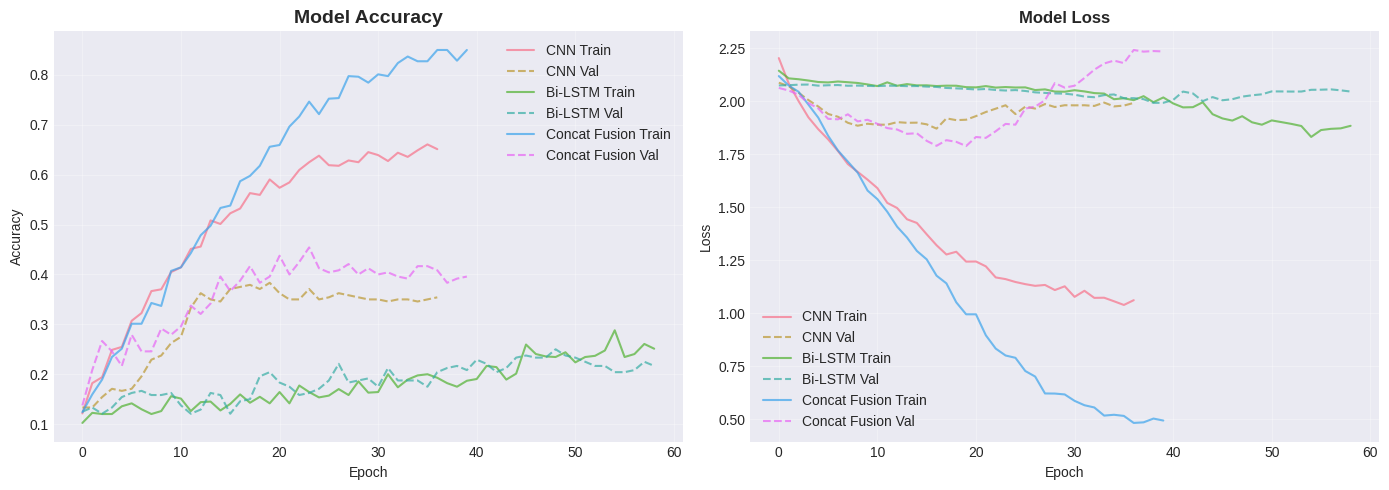

In [ ]:
def plot_training_curves(histories, names):
    """Plot training/validation curves for all models"""

    os.makedirs('results_corrected', exist_ok=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    for history, name in zip(histories, names):
        axes[0].plot(history.history['accuracy'], label=f'{name} Train', alpha=0.7)
        axes[0].plot(history.history['val_accuracy'], label=f'{name} Val', linestyle='--', alpha=0.7)

    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    for history, name in zip(histories, names):
        axes[1].plot(history.history['loss'], label=f'{name} Train', alpha=0.7)
        axes[1].plot(history.history['val_loss'], label=f'{name} Val', linestyle='--', alpha=0.7)

    axes[1].set_title('Model Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results_corrected/baseline_training_curves.png', dpi=150)
    plt.show()

plot_training_curves(
    [cnn_history, lstm_history, concat_history],
    ['CNN', 'Bi-LSTM', 'Concat Fusion']
)


In [ ]:
print("\n" + "="*60)
print("BASELINE RESULTS SUMMARY")
print("="*60)

results_df = pd.DataFrame({
    'Model': ['CNN-only (Spectral)', 'Bi-LSTM (Spectral)', 'Concatenation Fusion'],
    'Val Accuracy': [cnn_history.history['val_accuracy'][-1], lstm_history.history['val_accuracy'][-1], concat_history.history['val_accuracy'][-1]],
    'Test Accuracy': [cnn_results['accuracy'], lstm_results['accuracy'], concat_results['accuracy']],
    'Test F1-Score': [cnn_results['f1_weighted'], lstm_results['f1_weighted'], concat_results['f1_weighted']],
    'Parameters': [
        cnn_model.count_params(),
        lstm_model.count_params(),
        concat_model.count_params()
    ]
})

print("\n" + results_df.to_string(index=False))

# Ensure the directory exists before saving
os.makedirs('results_corrected', exist_ok=True)

# Save results
results_df.to_csv('results_corrected/baseline_results.csv', index=False)

# Save for paper (LaTeX format)
with open('results_corrected/baseline_results_latex.txt', 'w') as f:
    f.write("\\begin{table}[h]\\n")
    f.write("\\centering\\n")
    f.write("\\caption{Baseline Model Results}\\n")
    f.write("\\begin{tabular}{lcccc}\\n")
    f.write("\\hline\\n")
    f.write("Model & Val Acc & Test Acc & F1-Score & Params \\\\n")
    f.write("\\hline\\n")

    for _, row in results_df.iterrows():
        f.write(f"{row['Model']} & ")
        f.write(f"{row['Val Accuracy']*100:.1f}\\% & ")
        f.write(f"{row['Test Accuracy']*100:.1f}\\% & ")
        f.write(f"{row['Test F1-Score']:.3f} & ")
        f.write(f"{row['Parameters']/1e6:.2f}M \\\\n")

    f.write("\\hline\\n")
    f.write("\\end{tabular}\\n")
    f.write("\\end{table}\\n")

print("\n\u2713 Results saved:")
print("  - results_corrected/baseline_results.csv")
print("  - results_corrected/baseline_results_latex.txt")
print("  - Confusion matrices in results_corrected/")
print("  - Training curves in results_corrected/")


BASELINE RESULTS SUMMARY

               Model  Val Accuracy  Test Accuracy  Test F1-Score  Parameters
 CNN-only (Spectral)      0.354167       0.411111       0.384422      320328
  Bi-LSTM (Spectral)      0.216667       0.202778       0.117143      814216
Concatenation Fusion      0.395833       0.452778       0.418972      616200

✓ Results saved:
  - results_corrected/baseline_results.csv
  - results_corrected/baseline_results_latex.txt
  - Confusion matrices in results_corrected/
  - Training curves in results_corrected/


RUNNING DIAGNOSTICS

1. DATA SHAPES:
   Train: spec=(840, 165, 248), pros=(840, 165, 8), y=(840,)
   Val: spec=(240, 165, 248), pros=(240, 165, 8), y=(240,)
   Test: spec=(360, 165, 248), pros=(360, 165, 8), y=(360,)

2. LABEL DISTRIBUTION:
   Train labels: [ 56 112 112 112 112 112 112 112]
   Val labels: [16 32 32 32 32 32 32 32]
   Test labels: [24 48 48 48 48 48 48 48]
   Label range: 0-7

3. FEATURE STATISTICS:
   Spectral train - mean: -0.0000, std: 1.0000
   Spectral train - min: -13.1642, max: 12.1305
   Prosodic train - mean: 0.0000, std: 1.0000
   Prosodic train - min: -28.0007, max: 29.7856

4. DATA QUALITY:
   Spectral NaN: 0
   Spectral Inf: 0
   Prosodic NaN: 0
   Prosodic Inf: 0

5. PADDING ANALYSIS:
   Non-zero frames: 138600/138600
   Padding ratio: 0.00%

6. SAMPLE VISUALIZATION:


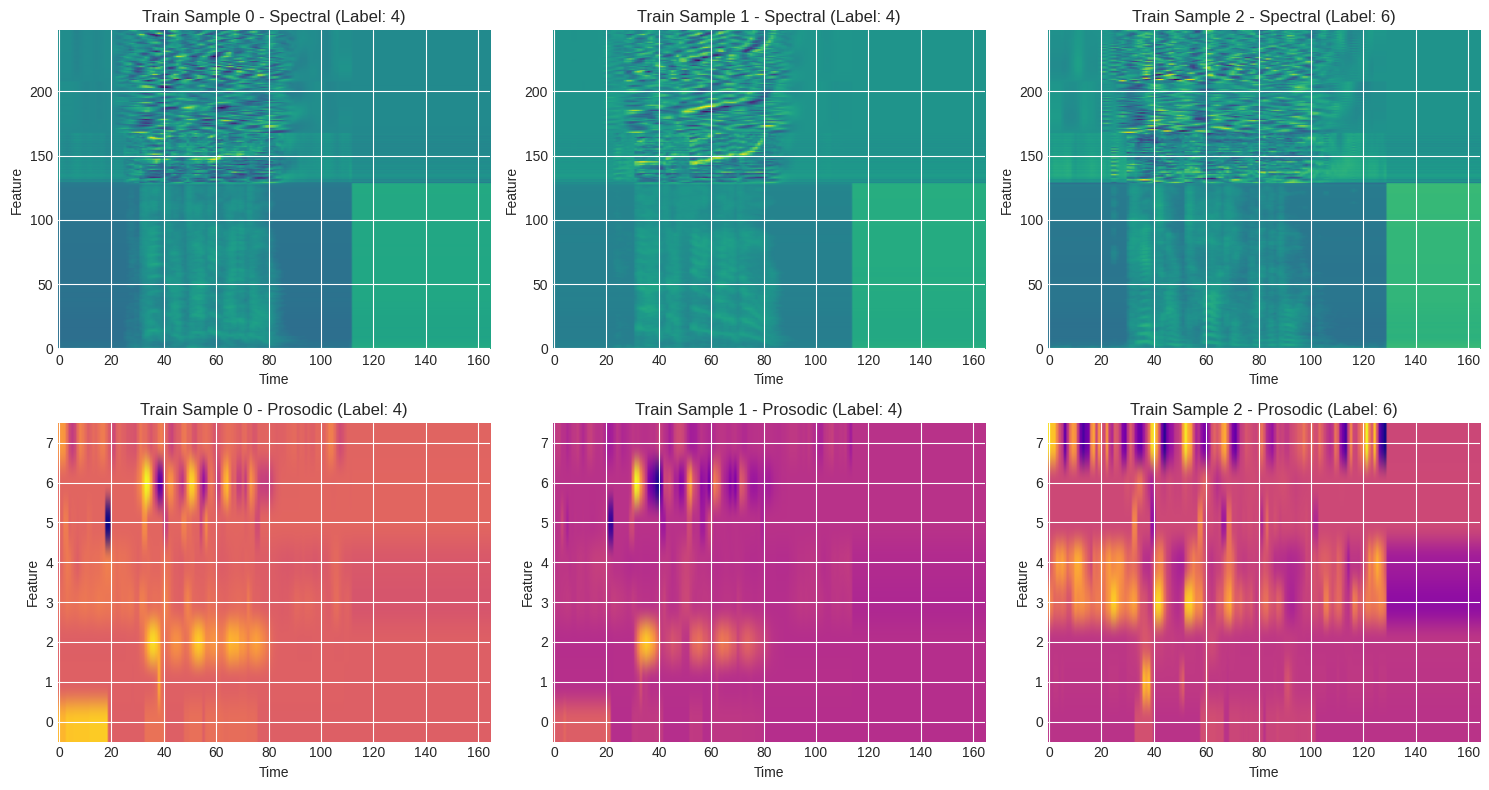

   ✓ Saved to diagnostic_samples.png

7. OVERFITTING SANITY CHECK
Testing if model CAN learn (should overfit on small data)...
Tiny dataset: (50, 165, 248), labels: [2 6 8 5 7 8 7 7]

Training on 50 samples for 50 epochs (should reach ~100% if working)...
Final training accuracy: 0.9600
✅ PASS: Model CAN learn (overfits small data)


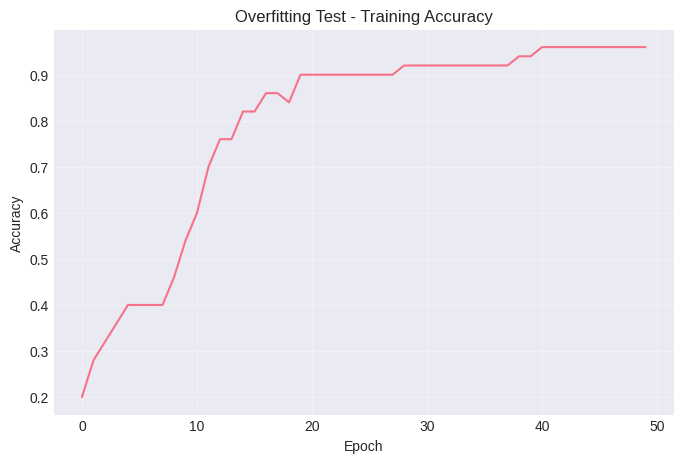

✓ Saved to diagnostic_overfit_test.png

8. CLASS IMBALANCE CHECK

Class distribution:
  Class 0: train= 56, val=16, test=24
  Class 1: train=112, val=32, test=48
  Class 2: train=112, val=32, test=48
  Class 3: train=112, val=32, test=48
  Class 4: train=112, val=32, test=48
  Class 5: train=112, val=32, test=48
  Class 6: train=112, val=32, test=48
  Class 7: train=112, val=32, test=48

Recommended class weights: {0: np.float64(1.875), 1: np.float64(0.9375), 2: np.float64(0.9375), 3: np.float64(0.9375), 4: np.float64(0.9375), 5: np.float64(0.9375), 6: np.float64(0.9375), 7: np.float64(0.9375)}

9. FEATURE NORMALIZATION CHECK

Train:
  Spectral - mean: -0.0000, std: 1.0000
  Prosodic - mean: 0.0000, std: 1.0000

Val:
  Spectral - mean: 0.0335, std: 0.9937
  Prosodic - mean: -0.0155, std: 0.9469

Test:
  Spectral - mean: 0.0357, std: 0.9960
  Prosodic - mean: -0.0160, std: 1.0057

✅ Features appear properly normalized

DIAGNOSTIC SUMMARY

✅ No obvious data issues detected
   Problem may

In [ ]:
# ============================================================
# DIAGNOSTIC SCRIPT - FIND THE PROBLEM
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

print("="*60)
print("RUNNING DIAGNOSTICS")
print("="*60)

# Load data
X_spec_train = np.load('features/X_spec_train.npy')
X_pros_train = np.load('features/X_pros_train.npy')
y_train = np.load('features/y_train.npy')

X_spec_val = np.load('features/X_spec_val.npy')
X_pros_val = np.load('features/X_pros_val.npy')
y_val = np.load('features/y_val.npy')

X_spec_test = np.load('features/X_spec_test.npy')
X_pros_test = np.load('features/X_pros_test.npy')
y_test = np.load('features/y_test.npy')

print(f"\n1. DATA SHAPES:")
print(f"   Train: spec={X_spec_train.shape}, pros={X_pros_train.shape}, y={y_train.shape}")
print(f"   Val: spec={X_spec_val.shape}, pros={X_pros_val.shape}, y={y_val.shape}")
print(f"   Test: spec={X_spec_test.shape}, pros={X_pros_test.shape}, y={y_test.shape}")

# Check 1: Label distribution
print(f"\n2. LABEL DISTRIBUTION:")
print(f"   Train labels: {np.bincount(y_train)}")
print(f"   Val labels: {np.bincount(y_val)}")
print(f"   Test labels: {np.bincount(y_test)}")
print(f"   Label range: {y_train.min()}-{y_train.max()}")

# Check 2: Feature statistics
print(f"\n3. FEATURE STATISTICS:")
print(f"   Spectral train - mean: {X_spec_train.mean():.4f}, std: {X_spec_train.std():.4f}")
print(f"   Spectral train - min: {X_spec_train.min():.4f}, max: {X_spec_train.max():.4f}")
print(f"   Prosodic train - mean: {X_pros_train.mean():.4f}, std: {X_pros_train.std():.4f}")
print(f"   Prosodic train - min: {X_pros_train.min():.4f}, max: {X_pros_train.max():.4f}")

# Check 3: NaN or Inf values
print(f"\n4. DATA QUALITY:")
print(f"   Spectral NaN: {np.isnan(X_spec_train).sum()}")
print(f"   Spectral Inf: {np.isinf(X_spec_train).sum()}")
print(f"   Prosodic NaN: {np.isnan(X_pros_train).sum()}")
print(f"   Prosodic Inf: {np.isinf(X_pros_train).sum()}")

# Check 4: Padding ratio
non_zero_frames = np.count_nonzero(X_spec_train.sum(axis=-1))
total_frames = X_spec_train.shape[0] * X_spec_train.shape[1]
print(f"\n5. PADDING ANALYSIS:")
print(f"   Non-zero frames: {non_zero_frames}/{total_frames}")
print(f"   Padding ratio: {1 - non_zero_frames/total_frames:.2%}")

# Check 5: Visualize a few samples
print(f"\n6. SAMPLE VISUALIZATION:")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i in range(3):
    # Spectral
    axes[0, i].imshow(X_spec_train[i].T, aspect='auto', cmap='viridis', origin='lower')
    axes[0, i].set_title(f'Train Sample {i} - Spectral (Label: {y_train[i]})')
    axes[0, i].set_xlabel('Time')
    axes[0, i].set_ylabel('Feature')

    # Prosodic
    axes[1, i].imshow(X_pros_train[i].T, aspect='auto', cmap='plasma', origin='lower')
    axes[1, i].set_title(f'Train Sample {i} - Prosodic (Label: {y_train[i]})')
    axes[1, i].set_xlabel('Time')
    axes[1, i].set_ylabel('Feature')

plt.tight_layout()
plt.savefig('diagnostic_samples.png', dpi=150)
plt.show()
print("   ✓ Saved to diagnostic_samples.png")

# ============================================================
# QUICK SANITY CHECK: TINY OVERFITTING TEST
# ============================================================

print(f"\n{'='*60}")
print("7. OVERFITTING SANITY CHECK")
print("="*60)
print("Testing if model CAN learn (should overfit on small data)...")

# Take just 50 samples
X_tiny = X_spec_train[:50]
y_tiny = y_train[:50]

print(f"Tiny dataset: {X_tiny.shape}, labels: {np.bincount(y_tiny)}")

# Build simple model
model = keras.Sequential([
    layers.Input(shape=(X_tiny.shape[1], X_tiny.shape[2])),
    layers.Conv1D(32, 3, activation='relu', padding='same'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(8, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining on 50 samples for 50 epochs (should reach ~100% if working)...")
history = model.fit(
    X_tiny, y_tiny,
    epochs=50,
    batch_size=16,
    verbose=0
)

final_acc = history.history['accuracy'][-1]
print(f"Final training accuracy: {final_acc:.4f}")

if final_acc > 0.95:
    print("✅ PASS: Model CAN learn (overfits small data)")
elif final_acc > 0.7:
    print("⚠️  PARTIAL: Model learning slowly")
else:
    print("❌ FAIL: Model CANNOT learn - fundamental issue!")

# Plot learning curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'])
plt.title('Overfitting Test - Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.savefig('diagnostic_overfit_test.png', dpi=150)
plt.show()
print("✓ Saved to diagnostic_overfit_test.png")

# ============================================================
# CHECK CLASS IMBALANCE IMPACT
# ============================================================

print(f"\n{'='*60}")
print("8. CLASS IMBALANCE CHECK")
print("="*60)

train_counts = np.bincount(y_train)
val_counts = np.bincount(y_val)
test_counts = np.bincount(y_test)

print("\nClass distribution:")
for i in range(8):
    print(f"  Class {i}: train={train_counts[i]:3d}, val={val_counts[i]:2d}, test={test_counts[i]:2d}")

# Calculate class weights
total = len(y_train)
class_weights = {i: total / (8 * count) for i, count in enumerate(train_counts)}
print("\nRecommended class weights:", class_weights)

# ============================================================
# CHECK FEATURE NORMALIZATION
# ============================================================

print(f"\n{'='*60}")
print("9. FEATURE NORMALIZATION CHECK")
print("="*60)

# Check if features are properly normalized
for split_name, X_spec, X_pros in [
    ("Train", X_spec_train, X_pros_train),
    ("Val", X_spec_val, X_pros_val),
    ("Test", X_spec_test, X_pros_test)
]:
    print(f"\n{split_name}:")
    print(f"  Spectral - mean: {X_spec.mean():.4f}, std: {X_spec.std():.4f}")
    print(f"  Prosodic - mean: {X_pros.mean():.4f}, std: {X_pros.std():.4f}")

# If mean is NOT close to 0 and std NOT close to 1, normalization failed
if abs(X_spec_train.mean()) > 0.1 or abs(X_spec_train.std() - 1.0) > 0.2:
    print("\n⚠️  WARNING: Features may not be properly normalized!")
else:
    print("\n✅ Features appear properly normalized")

# ============================================================
# SUMMARY & RECOMMENDATIONS
# ============================================================

print(f"\n{'='*60}")
print("DIAGNOSTIC SUMMARY")
print("="*60)

issues = []

# Check 1: Very high padding
if 1 - non_zero_frames/total_frames > 0.6:
    issues.append("High padding ratio (>60%) - may need masking layers")

# Check 2: Class imbalance
if train_counts.max() / train_counts.min() > 2:
    issues.append("Class imbalance - use class_weight in model.fit()")

# Check 3: Poor normalization
if abs(X_spec_train.mean()) > 0.1:
    issues.append("Features not normalized - rerun Phase 2 with proper StandardScaler")

# Check 4: NaN/Inf
if np.isnan(X_spec_train).sum() > 0 or np.isinf(X_spec_train).sum() > 0:
    issues.append("NaN or Inf values in features - check feature extraction")

if issues:
    print("\n🔴 ISSUES FOUND:")
    for i, issue in enumerate(issues, 1):
        print(f"  {i}. {issue}")
else:
    print("\n✅ No obvious data issues detected")
    print("   Problem may be in model architecture or training")

print("\n" + "="*60)
print("NEXT STEPS:")
print("="*60)
print("1. Review diagnostic_samples.png - do features look reasonable?")
print("2. Check diagnostic_overfit_test.png - does model learn on small data?")
print("3. If overfitting test fails, there's a fundamental issue")
print("4. If it passes, we need to adjust training (class weights, masking, etc)")
print("="*60)

In [ ]:
print("\n" + "="*60)
print("LOADING DATA")
print("="*60)

X_spec_train = np.load('features/X_spec_train.npy')
X_pros_train = np.load('features/X_pros_train.npy')
y_train = np.load('features/y_train.npy')

X_spec_val = np.load('features/X_spec_val.npy')
X_pros_val = np.load('features/X_pros_val.npy')
y_val = np.load('features/y_val.npy')

X_spec_test = np.load('features/X_spec_test.npy')
X_pros_test = np.load('features/X_pros_test.npy')
y_test = np.load('features/y_test.npy')

print(f"Train: {X_spec_train.shape[0]} samples")
print(f"Val: {X_spec_val.shape[0]} samples")
print(f"Test: {X_spec_test.shape[0]} samples")


LOADING DATA
Train: 840 samples
Val: 240 samples
Test: 360 samples


In [ ]:
train_counts = np.bincount(y_train)
total = len(y_train)
class_weights = {i: total / (8 * count) for i, count in enumerate(train_counts)}

print(f"\nClass distribution: {train_counts}")
print(f"Class weights: {class_weights}")

# Create directories
os.makedirs('results_corrected', exist_ok=True)
os.makedirs('models_corrected', exist_ok=True)

EMOTION_NAMES = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
NUM_CLASSES = 8


Class distribution: [ 56 112 112 112 112 112 112 112]
Class weights: {0: np.float64(1.875), 1: np.float64(0.9375), 2: np.float64(0.9375), 3: np.float64(0.9375), 4: np.float64(0.9375), 5: np.float64(0.9375), 6: np.float64(0.9375), 7: np.float64(0.9375)}


In [ ]:
def plot_confusion_matrix(y_true, y_pred, title, save_path):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTION_NAMES,
                yticklabels=EMOTION_NAMES)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

def plot_history(history, title, save_path):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title(f'{title} - Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title(f'{title} - Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    f1_macro = f1_score(y_true, y_pred, average='macro')

    print(f"\n{model_name} Results:")
    print(f"  Test Accuracy: {accuracy:.4f}")
    print(f"  F1-Score (weighted): {f1_weighted:.4f}")
    print(f"  F1-Score (macro): {f1_macro:.4f}")

    report = classification_report(y_true, y_pred, target_names=EMOTION_NAMES, digits=4)
    print(f"\n{report}")

    return {
        'accuracy': float(accuracy),
        'f1_weighted': float(f1_weighted),
        'f1_macro': float(f1_macro),
        'report': report
    }


In [ ]:
print("\n" + "="*60)
print("BASELINE 1: CNN-ONLY (SPECTRAL)")
print("="*60)

def build_cnn_baseline(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # Add masking for padded sequences
    x = layers.Masking(mask_value=0.0)(inputs)

    # Conv blocks
    x = layers.Conv1D(64, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(128, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(256, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Classification
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs=inputs, outputs=outputs, name='CNN_Baseline')

cnn_model = build_cnn_baseline(
    input_shape=(X_spec_train.shape[1], X_spec_train.shape[2]),
    num_classes=NUM_CLASSES
)

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # LOWER LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
    ModelCheckpoint('models_corrected/cnn_baseline.keras', save_best_only=True,
                   monitor='val_accuracy', verbose=1)
]

print("Training CNN baseline...")
cnn_history = cnn_model.fit(
    X_spec_train, y_train,
    validation_data=(X_spec_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,  # CRITICAL FIX!
    callbacks=cnn_callbacks,
    verbose=1
)

# Evaluate
y_pred_cnn = np.argmax(cnn_model.predict(X_spec_test, verbose=0), axis=1)
cnn_results = evaluate_model(y_test, y_pred_cnn, "CNN Baseline")

plot_history(cnn_history, "CNN Baseline", "results_/history_cnn.png")
plot_confusion_matrix(y_test, y_pred_cnn, "CNN Baseline", "results/cm_cnn.png")


BASELINE 1: CNN-ONLY (SPECTRAL)
Training CNN baseline...
Epoch 1/100
